  SECTION 5.2 – MONTE CARLO RESULTS  (improved model)
  Failures               :      271  of  100,000,000
  Surviving              : 99,999,729  of  100,000,000
  Failure rate           :   0.0003 %
  Per-storm Pf           : 2.71e-06
  95% CI (per storm)     : [2.39e-06,  3.03e-06]
  Reliability index β    :    4.548
  Per-storm target β     :    4.540

  Annual Pf (λ=3.56 storms/yr) : 9.64e-06
  95% CI (annual)        : [8.49e-06,  1.08e-05]
  ULS annual target      : 1.00e-05
  Meets ULS target?      :    YES ✓

  SAMPLE STATISTICS
  Variable            Mean       Std  Unit
  --------------------------------------------
  Hs                  4.34      0.64  m
  Tp                  7.26      0.74  s
  Hmax                8.68      1.24  m
  DAF                1.280     0.081  -  (max=9.06)
  S (total)          23.49      1.49  MN
  R                  59.85      4.19  MN
  g(X)=R-S           36.36      4.45  MN

  SENSITIVITY – fixed DAF (for comparison with original notebook)
  DAF 

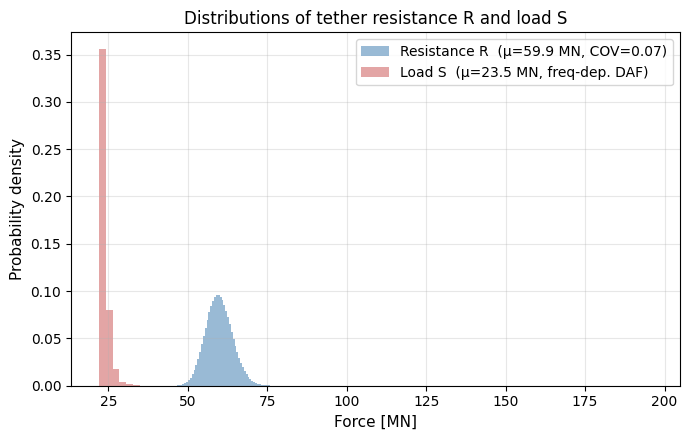

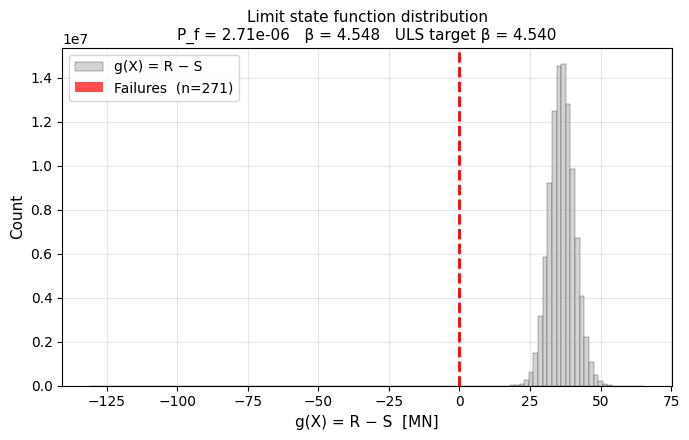

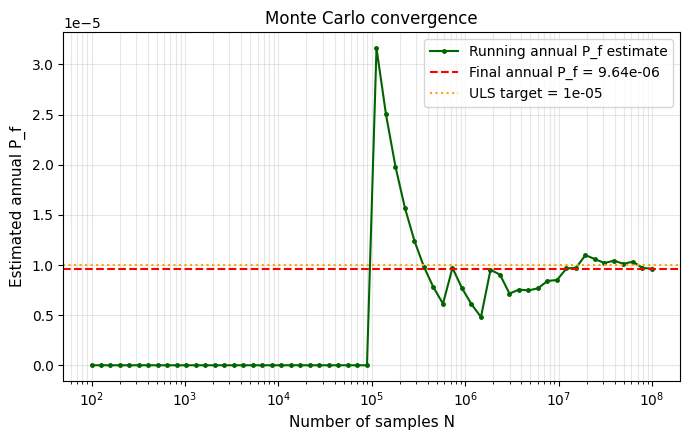

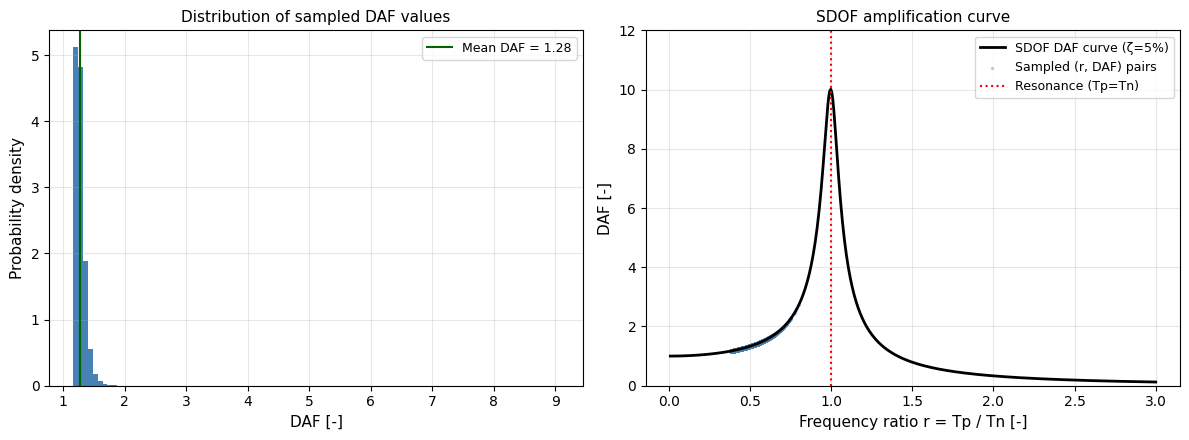

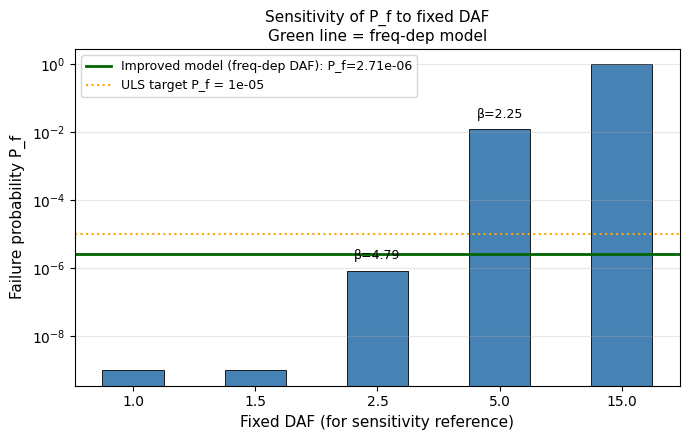

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# ── DATA & PARAMETERS ────────────────────────────────────────

Hs_peaks = np.array([
    3.9, 4.1, 4.2, 3.8, 3.8, 5.7, 3.9, 4.2, 6.0, 3.7,
    4.6, 4.3, 3.7, 4.7, 3.7, 3.9, 4.0, 4.4, 4.2, 4.2,
    4.8, 4.7, 4.2, 4.2, 4.8, 4.7, 5.1, 4.9, 4.2, 3.9,
    4.6, 3.9
])

u        = 3.7
n_years  = 9
lam      = len(Hs_peaks) / n_years
beta_exp = (Hs_peaks - u).mean()

g_acc    = 9.81
Sp_lo, Sp_hi = 1/25, 1/15

# Structural parameters (Sections 4.4.1 and 3.2)
Tn   = 15.66
zeta = 0.05

# Mooring / load parameters (Sections 2.2.2, 3.2, 3.4)
T0        = 16.3
k         = 13.4e-3
L_b       = 192
n_tethers = 4

# Resistance: lognormal (Section 3.4)
MBL      = 57.0
mu_R     = MBL * 1.05
COV_R    = 0.07
sigma_R  = COV_R * mu_R
sigma_ln = np.sqrt(np.log(1 + (sigma_R / mu_R)**2))
mu_ln    = np.log(mu_R) - 0.5 * sigma_ln**2

N                 = 1_000_00000
P_f_target_annual = 1e-5
P_f_target_storm  = 1 - (1 - P_f_target_annual) ** (1 / lam)

# ── SAMPLING ─────────────────────────────────────────────────

Hs_s = u + np.random.exponential(beta_exp, N)

Sp_s = np.random.uniform(Sp_lo, Sp_hi, N)
Tp_s = np.sqrt(2 * np.pi * Hs_s / (g_acc * Sp_s))

N_waves_s = (6 * 3600) / Tp_s
Hmax_s    = Hs_s * np.sqrt(np.log(N_waves_s) / 2)

r_s   = Tp_s / Tn
DAF_s = 1.0 / np.sqrt((1 - r_s**2)**2 + (2 * zeta * r_s)**2)

S_wave_s = k * Hmax_s * L_b / n_tethers
S_s      = T0 + S_wave_s * DAF_s

R_s = np.random.lognormal(mu_ln, sigma_ln, N)
g_s = R_s - S_s

# ── RESULTS ──────────────────────────────────────────────────

n_fail     = np.sum(g_s <= 0)
P_f        = n_fail / N
P_f_annual = 1 - (1 - P_f) ** lam
beta_rel   = -norm.ppf(P_f) if 0 < P_f < 1 else (np.inf if P_f == 0 else -np.inf)
se_Pf      = np.sqrt(P_f * (1 - P_f) / N)
CI_lo      = max(0, P_f - 1.96 * se_Pf)
CI_hi      = P_f + 1.96 * se_Pf

CI_lo_annual = 1 - (1 - CI_lo) ** lam
CI_hi_annual = 1 - (1 - CI_hi) ** lam

sizes             = np.unique(np.logspace(2, np.log10(N), 60).astype(int))
Pf_running        = [np.sum(g_s[:n] <= 0) / n for n in sizes]
Pf_annual_running = [1 - (1 - pf) ** lam for pf in Pf_running]

DAF_vals = [1.0, 1.5, 2.5, 5.0, 15.0]
Pf_DAF, beta_DAF = [], []
for daf in DAF_vals:
    g_t = R_s - (T0 + S_wave_s * daf)
    pf  = np.sum(g_t <= 0) / N
    b   = -norm.ppf(pf) if 0 < pf < 1 else (np.inf if pf == 0 else -np.inf)
    Pf_DAF.append(pf)
    beta_DAF.append(b)

# ── PRINT RESULTS ────────────────────────────────────────────

W = 68
print("=" * W)
print("  SECTION 5.2 – MONTE CARLO RESULTS  (improved model)")
print("=" * W)
print(f"  Failures               : {n_fail:>8,}  of  {N:,}")
print(f"  Surviving              : {N-n_fail:>8,}  of  {N:,}")
print(f"  Failure rate           : {P_f*100:>8.4f} %")
print(f"  Per-storm Pf           : {P_f:>8.2e}")
print(f"  95% CI (per storm)     : [{CI_lo:.2e},  {CI_hi:.2e}]")
b_str = f"{beta_rel:>8.3f}" if np.isfinite(beta_rel) else "    >4.75"
print(f"  Reliability index β    : {b_str}")
print(f"  Per-storm target β     : {-norm.ppf(P_f_target_storm):>8.3f}")
print()
print(f"  Annual Pf (λ={lam:.2f} storms/yr) : {P_f_annual:>8.2e}")
print(f"  95% CI (annual)        : [{CI_lo_annual:.2e},  {CI_hi_annual:.2e}]")
print(f"  ULS annual target      : {P_f_target_annual:>8.2e}")
print(f"  Meets ULS target?      : {'YES ✓' if P_f_annual <= P_f_target_annual else 'NO – redesign needed':>8}")
print()
print("  SAMPLE STATISTICS")
print(f"  {'Variable':<14} {'Mean':>9} {'Std':>9}  Unit")
print("  " + "-" * 44)
print(f"  {'Hs':<14} {Hs_s.mean():>9.2f} {Hs_s.std():>9.2f}  m")
print(f"  {'Tp':<14} {Tp_s.mean():>9.2f} {Tp_s.std():>9.2f}  s")
print(f"  {'Hmax':<14} {Hmax_s.mean():>9.2f} {Hmax_s.std():>9.2f}  m")
print(f"  {'DAF':<14} {DAF_s.mean():>9.3f} {DAF_s.std():>9.3f}  -  (max={DAF_s.max():.2f})")
print(f"  {'S (total)':<14} {S_s.mean():>9.2f} {S_s.std():>9.2f}  MN")
print(f"  {'R':<14} {R_s.mean():>9.2f} {R_s.std():>9.2f}  MN")
print(f"  {'g(X)=R-S':<14} {g_s.mean():>9.2f} {g_s.std():>9.2f}  MN")
print()
print("  SENSITIVITY – fixed DAF (for comparison with original notebook)")
print(f"  {'DAF':<6} {'mu_S':>8} {'Failures':>10} {'Fail %':>10} {'Pf':>10} {'β':>7}")
print("  " + "-" * 55)
for daf, pf, b in zip(DAF_vals, Pf_DAF, beta_DAF):
    nf   = int(round(pf * N))
    b_s  = f"{b:.3f}" if np.isfinite(b) else ">4.75"
    mu_s = (T0 + S_wave_s * daf).mean()
    print(f"  {daf:<6} {mu_s:>8.2f} {nf:>10,} {pf*100:>9.4f}% {pf:>10.2e} {b_s:>7}")
print("=" * W)

# ── FIGURE 1 – R and S distributions ─────────────────────────

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(R_s, bins=80, alpha=0.55, color="steelblue", density=True,
        label=f"Resistance R  (μ={mu_R:.1f} MN, COV={COV_R})")
ax.hist(S_s, bins=80, alpha=0.55, color="indianred", density=True,
        label=f"Load S  (μ={S_s.mean():.1f} MN, freq-dep. DAF)")
ax.set_xlabel("Force [MN]", fontsize=11)
ax.set_ylabel("Probability density", fontsize=11)
ax.set_title("Distributions of tether resistance R and load S", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── FIGURE 2 – g(X) histogram ────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(g_s, bins=120, color="lightgray", edgecolor="black",
        linewidth=0.2, label="g(X) = R − S")
if np.any(g_s <= 0):
    ax.hist(g_s[g_s <= 0],
            bins=np.linspace(g_s.min(), 0, 20),
            color="red", alpha=0.7, label=f"Failures  (n={n_fail})")
ax.axvline(0, color="red", linestyle="--", linewidth=2)
ax.set_xlabel("g(X) = R − S  [MN]", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
b_title = f"{beta_rel:.3f}" if np.isfinite(beta_rel) else ">4.75"
ax.set_title(
    f"Limit state function distribution\n"
    f"P_f = {P_f:.2e}   β = {b_title}   "
    f"ULS target β = {-norm.ppf(P_f_target_storm):.3f}",
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── FIGURE 3 – Convergence (annual Pf) ───────────────────────

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(sizes, Pf_annual_running, marker="o", markersize=2.5,
            color="darkgreen", label="Running annual P_f estimate")
ax.axhline(P_f_annual, color="red", linestyle="--", linewidth=1.5,
           label=f"Final annual P_f = {P_f_annual:.2e}")
ax.axhline(P_f_target_annual, color="orange", linestyle=":", linewidth=1.5,
           label=f"ULS target = {P_f_target_annual:.0e}")
ax.set_xlabel("Number of samples N", fontsize=11)
ax.set_ylabel("Estimated annual P_f", fontsize=11)
ax.set_title("Monte Carlo convergence", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

# ── FIGURE 4 – DAF distribution ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(DAF_s, bins=100, color="steelblue", edgecolor="none", density=True)
axes[0].axvline(DAF_s.mean(), color="darkgreen", linestyle="-", linewidth=1.5,
                label=f"Mean DAF = {DAF_s.mean():.2f}")
axes[0].set_xlabel("DAF [-]", fontsize=11)
axes[0].set_ylabel("Probability density", fontsize=11)
axes[0].set_title("Distribution of sampled DAF values", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

r_range   = np.linspace(0.01, 3.0, 500)
DAF_curve = 1.0 / np.sqrt((1 - r_range**2)**2 + (2*zeta*r_range)**2)
axes[1].plot(r_range, DAF_curve, color="black", linewidth=2, label="SDOF DAF curve (ζ=5%)")
axes[1].scatter(r_s[::500], DAF_s[::500], s=2, alpha=0.3, color="steelblue",
                label="Sampled (r, DAF) pairs")
axes[1].axvline(1.0, color="red", linestyle=":", linewidth=1.5, label="Resonance (Tp=Tn)")
axes[1].set_xlabel("Frequency ratio r = Tp / Tn [-]", fontsize=11)
axes[1].set_ylabel("DAF [-]", fontsize=11)
axes[1].set_title("SDOF amplification curve", fontsize=11)
axes[1].set_ylim(0, 12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── FIGURE 5 – Sensitivity: fixed DAF comparison ─────────────

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([str(d) for d in DAF_vals],
              [max(p, 1e-9) for p in Pf_DAF],
              color="steelblue", edgecolor="black", linewidth=0.6, width=0.5)
for bar, b in zip(bars, beta_DAF):
    if np.isfinite(b):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.8,
                f"β={b:.2f}", ha="center", va="bottom", fontsize=9)

ax.axhline(P_f, color="darkgreen", linestyle="-", linewidth=2,
           label=f"Improved model (freq-dep DAF): P_f={P_f:.2e}")
ax.axhline(P_f_target_annual, color="orange", linestyle=":", linewidth=1.5,
           label=f"ULS target P_f = {P_f_target_annual:.0e}")
ax.set_xlabel("Fixed DAF (for sensitivity reference)", fontsize=11)
ax.set_ylabel("Failure probability P_f", fontsize=11)
ax.set_yscale("log")
ax.set_title(
    "Sensitivity of P_f to fixed DAF\n"
    "Green line = freq-dep model",
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y", which="both")
plt.tight_layout()
plt.show()